-> O Que é Regressão Linear?

-> Conceitos Importantes:
  -> Classificação
  -> Regressão
  -> Variável Independente ou Preditora
  -> Variável Alvo ou Dependente
  -> Aprendizado Supervisionado

-> Tipos de Regressão Linear:
  -> Regressão Linear Simples
  -> Regressão Linear Múltipla

-> O que é Correlação?

California Housing

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [24]:
# =============================================
#              REGRESSÃO LINEAR               #
# =============================================

print("=== MODELO DE REGRESSÃO LINEAR - CALIFORNIA HOUSING ===")

# Carregar dados
california = fetch_california_housing()
data = pd.DataFrame(california.data, columns=california.feature_names)
data['Preco'] = california.target * 100000  # Converter para dólares

print(f"Dataset: {data.shape[0]} casas, {data.shape[1]-1} features")
print("Algoritmo: Regressão Linear (LinearRegression)")

# Preparar dados
X = data.drop('Preco', axis=1)
y = data['Preco']

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

=== MODELO DE REGRESSÃO LINEAR - CALIFORNIA HOUSING ===
Dataset: 20640 casas, 8 features
Algoritmo: Regressão Linear (LinearRegression)


In [26]:
# =============================================
#       TREINAMENTO DA REGRESSÃO LINEAR      #
# =============================================

print("\n=== TREINAMENTO ===")

# Criar e treinar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Fazer predições
y_pred = model.predict(X_test)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"R²: {r2:.3f}")
print(f"Erro percentual médio: {(mae/y_test.mean())*100:.1f}%")



=== TREINAMENTO ===
RMSE: $74,558.14
MAE: $53,320.01
R²: 0.576
Erro percentual médio: 25.9%


In [27]:
# =============================================
#         ANÁLISE DOS COEFICIENTES           #
# =============================================

print("\n=== COEFICIENTES DA REGRESSÃO LINEAR ===")

# Coeficientes
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_,
    'Coef_Abs': np.abs(model.coef_)
}).sort_values('Coef_Abs', ascending=False)

print(f"Intercepto: ${model.intercept_:,.2f}")
print("\nCoeficientes (ordenados por magnitude):")
print(coeficientes[['Feature', 'Coeficiente']])

# Interpretação dos coeficientes
print("\n=== INTERPRETAÇÃO DOS COEFICIENTES ===")
print("Efeito de cada variável no preço:")
for _, row in coeficientes.head().iterrows():
    feature = row['Feature']
    coef = row['Coeficiente']
    if coef > 0:
        print(f"• {feature}: +${coef:,.0f} por unidade de aumento")
    else:
        print(f"• {feature}: ${coef:,.0f} por unidade de aumento")


=== COEFICIENTES DA REGRESSÃO LINEAR ===
Intercepto: $-3,702,327.77

Coeficientes (ordenados por magnitude):
      Feature   Coeficiente
3   AveBedrms  78314.490679
0      MedInc  44867.490967
7   Longitude -43370.806496
6    Latitude -41979.248659
2    AveRooms -12332.334283
1    HouseAge    972.425752
5    AveOccup   -352.631849
4  Population     -0.202962

=== INTERPRETAÇÃO DOS COEFICIENTES ===
Efeito de cada variável no preço:
• AveBedrms: +$78,314 por unidade de aumento
• MedInc: +$44,867 por unidade de aumento
• Longitude: $-43,371 por unidade de aumento
• Latitude: $-41,979 por unidade de aumento
• AveRooms: $-12,332 por unidade de aumento


In [28]:
# =============================================
#         EQUAÇÃO DA REGRESSÃO LINEAR        #
# =============================================

print("\n=== EQUAÇÃO DA REGRESSÃO LINEAR ===")
print("Preço = Intercepto + Σ(Coeficiente × Feature)")
print(f"\nPreço = {model.intercept_:,.0f}")
for feature, coef in zip(X.columns, model.coef_):
    sinal = "+" if coef >= 0 else ""
    print(f"        {sinal} {coef:,.0f} × {feature}")



=== EQUAÇÃO DA REGRESSÃO LINEAR ===
Preço = Intercepto + Σ(Coeficiente × Feature)

Preço = -3,702,328
        + 44,867 × MedInc
        + 972 × HouseAge
         -12,332 × AveRooms
        + 78,314 × AveBedrms
         -0 × Population
         -353 × AveOccup
         -41,979 × Latitude
         -43,371 × Longitude



=== VISUALIZAÇÕES ===


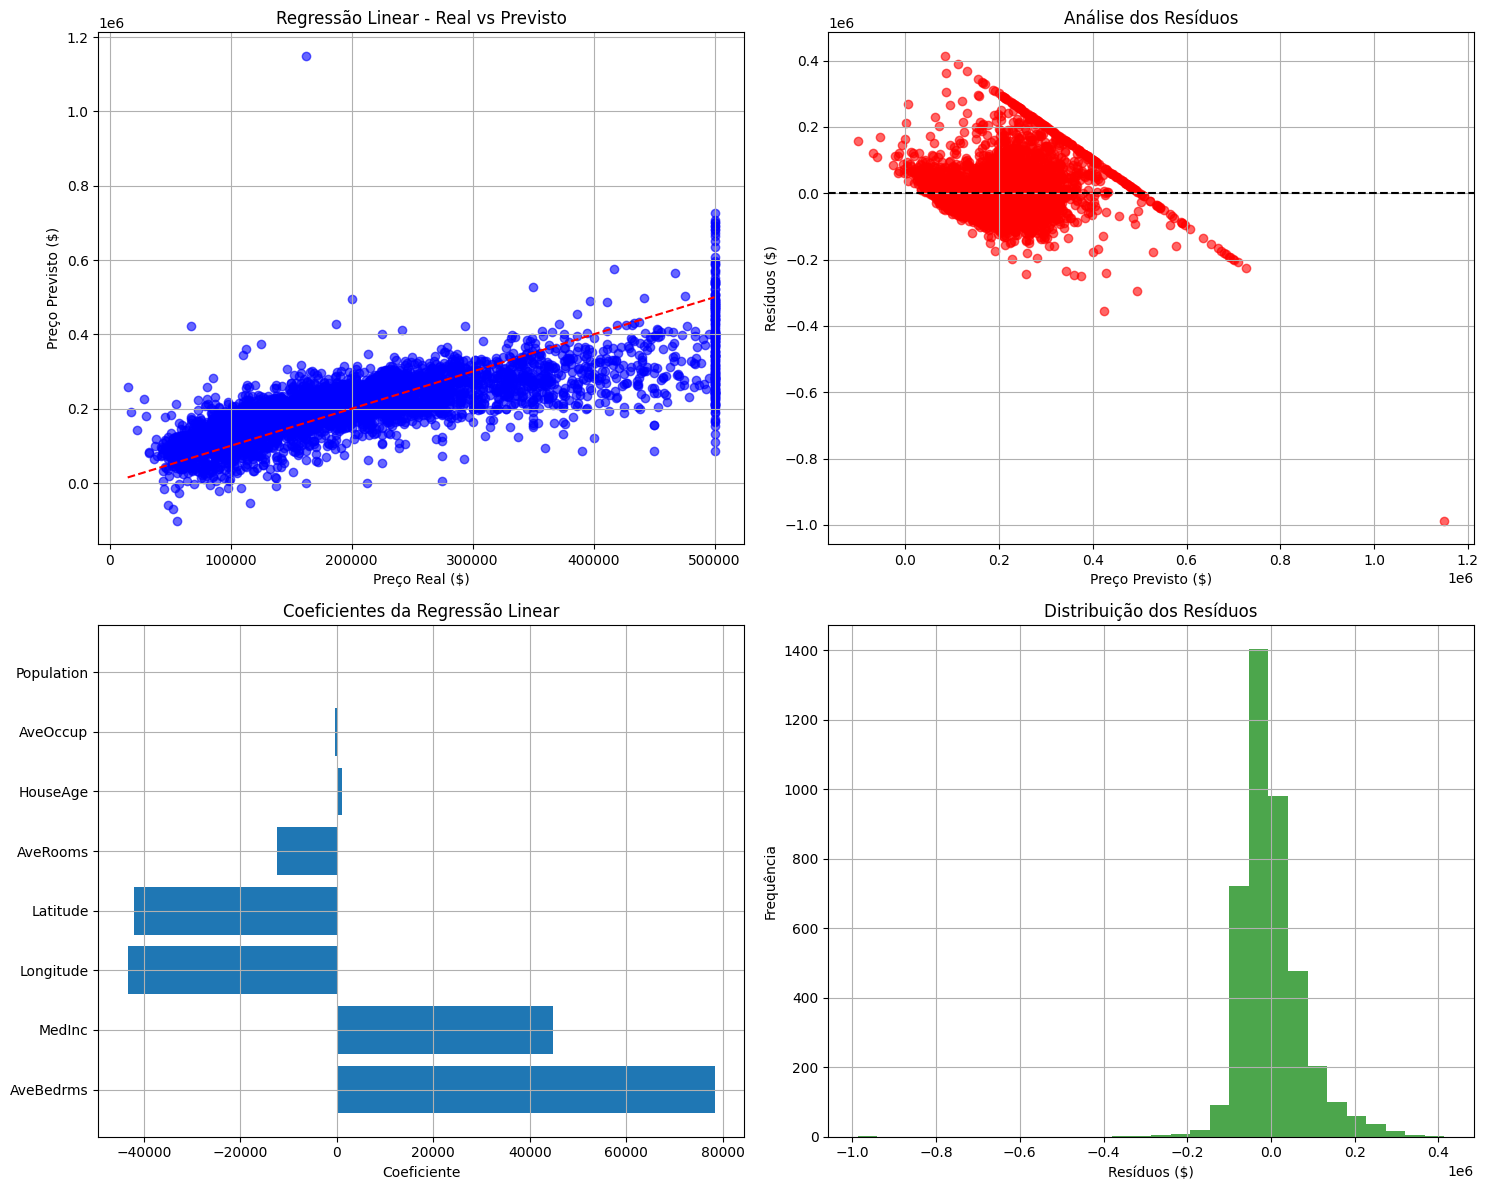

In [29]:
# =============================================
#                  VISUALIZAÇÕES             #
# =============================================

print("\n=== VISUALIZAÇÕES ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Real vs Previsto
axes[0, 0].scatter(y_test, y_pred, alpha=0.6, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 0].set_xlabel('Preço Real ($)')
axes[0, 0].set_ylabel('Preço Previsto ($)')
axes[0, 0].set_title('Regressão Linear - Real vs Previsto')
axes[0, 0].grid(True)

# 2. Resíduos
residuos = y_test - y_pred
axes[0, 1].scatter(y_pred, residuos, alpha=0.6, color='red')
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_xlabel('Preço Previsto ($)')
axes[0, 1].set_ylabel('Resíduos ($)')
axes[0, 1].set_title('Análise dos Resíduos')
axes[0, 1].grid(True)

# 3. Coeficientes
axes[1, 0].barh(coeficientes['Feature'], coeficientes['Coeficiente'])
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Coeficientes da Regressão Linear')
axes[1, 0].grid(True)

# 4. Histograma dos resíduos
axes[1, 1].hist(residuos, bins=30, alpha=0.7, color='green')
axes[1, 1].set_xlabel('Resíduos ($)')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Resíduos')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


In [30]:
# =============================================
#            VERIFICAÇÃO DAS PREMISSAS        #
# =============================================

print("\n=== VERIFICAÇÃO DAS PREMISSAS DA REGRESSÃO LINEAR ===")

# 1. Linearidade
print("1. LINEARIDADE:")
print("Modelo assume relação linear entre features e target")

# 2. Normalidade dos resíduos
from scipy import stats
_, p_value = stats.shapiro(residuos[:1000])  # Teste em amostra menor
print(f"\n2. NORMALIDADE DOS RESÍDUOS:")
print(f" Shapiro-Wilk p-value: {p_value:.4f}")
if p_value > 0.05:
    print("Resíduos seguem distribuição normal")
else:
    print("Resíduos NÃO seguem distribuição normal")

# 3. Homocedasticidade
print(f"\n3. HOMOCEDASTICIDADE:")
print("Verificar no gráfico de resíduos vs preditos")
print("Variância constante = pontos espalhados uniformemente")
print("Heterocedasticidade = padrão em funil")

# 4. Multicolinearidade
print(f"\n4. MULTICOLINEARIDADE:")
corr_matrix = X.corr()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    print("Correlações altas encontradas:")
    for var1, var2, corr in high_corr:
        print(f"{var1} vs {var2}: {corr:.3f}")
else:
    print("Sem multicolinearidade severa")


=== VERIFICAÇÃO DAS PREMISSAS DA REGRESSÃO LINEAR ===
1. LINEARIDADE:
Modelo assume relação linear entre features e target

2. NORMALIDADE DOS RESÍDUOS:
 Shapiro-Wilk p-value: 0.0000
Resíduos NÃO seguem distribuição normal

3. HOMOCEDASTICIDADE:
Verificar no gráfico de resíduos vs preditos
Variância constante = pontos espalhados uniformemente
Heterocedasticidade = padrão em funil

4. MULTICOLINEARIDADE:
Correlações altas encontradas:
AveRooms vs AveBedrms: 0.848
Latitude vs Longitude: -0.925


In [31]:
# =============================================
#               EXEMPLO DE PREDIÇÃO           #
# =============================================

print("\n=== EXEMPLO DE PREDIÇÃO ===")

# Casa exemplo
exemplo = pd.DataFrame({
    'MedInc': [5.0],           # Renda média: $50,000
    'HouseAge': [10.0],        # Idade: 10 anos
    'AveRooms': [6.0],         # Média de quartos: 6
    'AveBedrms': [1.2],        # Média de dormitórios: 1.2
    'Population': [3000.0],    # População: 3,000
    'AveOccup': [3.0],         # Ocupação média: 3
    'Latitude': [34.0],        # Latitude: 34°N
    'Longitude': [-118.0]      # Longitude: 118°W
})

preco_previsto = model.predict(exemplo)[0]

print("Casa exemplo:")
print(f"• Renda média da região: $50,000")
print(f"• Idade da casa: 10 anos")
print(f"• Média de quartos: 6")
print(f"• Localização: Los Angeles (aprox.)")
print(f"\nPreço previsto: ${preco_previsto:,.2f}")

# Cálculo manual usando a equação
calculo_manual = model.intercept_
for feature, coef in zip(X.columns, model.coef_):
    valor = exemplo[feature].iloc[0]
    contribuicao = coef * valor
    calculo_manual += contribuicao
    print(f"• {feature}: {coef:,.0f} × {valor} = ${contribuicao:,.0f}")

print(f"\nCálculo manual: ${calculo_manual:,.2f}")
print(f"Predição modelo: ${preco_previsto:,.2f}")
print(f"Diferença: ${abs(calculo_manual - preco_previsto):,.2f}")



=== EXEMPLO DE PREDIÇÃO ===
Casa exemplo:
• Renda média da região: $50,000
• Idade da casa: 10 anos
• Média de quartos: 6
• Localização: Los Angeles (aprox.)

Preço previsto: $240,511.26
• MedInc: 44,867 × 5.0 = $224,337
• HouseAge: 972 × 10.0 = $9,724
• AveRooms: -12,332 × 6.0 = $-73,994
• AveBedrms: 78,314 × 1.2 = $93,977
• Population: -0 × 3000.0 = $-609
• AveOccup: -353 × 3.0 = $-1,058
• Latitude: -41,979 × 34.0 = $-1,427,294
• Longitude: -43,371 × -118.0 = $5,117,755

Cálculo manual: $240,511.26
Predição modelo: $240,511.26
Diferença: $0.00


In [32]:
# =============================================
#                CONCLUSÕES                   #
# =============================================

print("\n=== CONCLUSÕES DA REGRESSÃO LINEAR ===")
print(f"1. R² = {r2:.3f}: Explica {r2*100:.1f}% da variação nos preços")
print(f"2. RMSE = ${rmse:,.0f}: Erro médio nas predições")
print(f"3. Modelo simples e interpretável")
print(f"4. Cada coeficiente mostra o efeito direto de cada variável")
print(f"5. Assume relações lineares (pode ser limitante)")

# Feature mais importante
feature_mais_importante = coeficientes.iloc[0]['Feature']
coef_mais_importante = coeficientes.iloc[0]['Coeficiente']
print(f"\n Feature mais importante: {feature_mais_importante}")
print(f" Impacto: ${coef_mais_importante:,.0f} por unidade")


=== CONCLUSÕES DA REGRESSÃO LINEAR ===
1. R² = 0.576: Explica 57.6% da variação nos preços
2. RMSE = $74,558: Erro médio nas predições
3. Modelo simples e interpretável
4. Cada coeficiente mostra o efeito direto de cada variável
5. Assume relações lineares (pode ser limitante)

 Feature mais importante: AveBedrms
 Impacto: $78,314 por unidade


Regressão Polinomial

Tipos de Polinômios
					Polinômio de 2 parâmetros (linha reta):
					y = interceptação + B1*x
					Polinômio de 3 parâmetros (uma curvatura):
					y = interceptação + B1*x + B2*x²
					Polinômio de 4 parâmetros (duas curvaturas):
					y = interceptação + B1*x + B2*x² + B3*x

Vantagens
Desvantagens
Exemplo Prático

In [50]:
#==================================
#   Previsão de Preços de Carros  #
#==================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'

In [51]:
# =============================================================================
#                    CARREGAMENTO E LIMPEZA DOS DADOS                         #
# =============================================================================

def carregar_dados():
    """Carrega dados do dataset de carros"""
    try:
        url = 'https://carapi.app/features/vehicle-csv-download'
        print("Carregando dados...")
        data = pd.read_csv(url)

        # Verificar colunas disponíveis
        if 'price' not in data.columns or 'mileage' not in data.columns:
            print("Colunas disponíveis:", data.columns.tolist())
            # Buscar colunas similares
            price_cols = [col for col in data.columns if 'price' in col.lower()]
            mileage_cols = [col for col in data.columns if 'mileage' in col.lower() or 'mile' in col.lower()]

            if price_cols and mileage_cols:
                price_col = price_cols[0]
                mileage_col = mileage_cols[0]
                print(f"Usando colunas: {price_col} e {mileage_col}")
                data = data[[price_col, mileage_col]]
                data.columns = ['price', 'mileage']
            else:
                raise ValueError("Colunas não encontradas")
        else:
            data = data[['price', 'mileage']]

        return data

    except Exception as e:
        print(f"Erro: {e}")
        print("Criando dados sintéticos...")
        return criar_dados_sinteticos()

def criar_dados_sinteticos():
    """Cria dados sintéticos para demonstração"""
    np.random.seed(42)
    n_samples = 1000
    mileage = np.random.uniform(0, 200000, n_samples)
    price = 35000 - 0.15 * mileage + 0.0000005 * mileage**2 + np.random.normal(0, 3000, n_samples)
    price = np.maximum(price, 1000)

    return pd.DataFrame({
        'mileage': mileage,
        'price': price
    })

def limpar_dados(data):
    """Limpa e prepara os dados"""
    # Remover valores nulos
    data = data.dropna()

    # Remover outliers extremos
    data = data[(data['price'] > 0) & (data['price'] < data['price'].quantile(0.95))]
    data = data[(data['mileage'] >= 0) & (data['mileage'] < data['mileage'].quantile(0.95))]

    print(f"Dataset final: {len(data)} registros")
    print(f"Preço médio: ${data['price'].mean():.2f}")
    print(f"Quilometragem média: {data['mileage'].mean():.0f} milhas")

    return data


In [52]:
# =============================================================================
#                              ANÁLISE EXPLORATÓRIA                           #
# =============================================================================

def explorar_dados(data):
    """Explora e visualiza os dados iniciais"""
    print("\n=== ANÁLISE EXPLORATÓRIA ===")
    print(f"Forma dos dados: {data.shape}")
    print(f"Estatísticas descritivas:")
    print(data.describe())

    # Correlação
    correlacao = data['mileage'].corr(data['price'])
    print(f"Correlação entre quilometragem e preço: {correlacao:.3f}")

def plotar_dados_iniciais(data):
    """Plota os dados originais"""
    plt.figure(figsize=(10, 6))
    plt.scatter(data['mileage'], data['price'], alpha=0.6, color='blue', s=20)
    plt.title('Preço vs Quilometragem - Dados Originais')
    plt.xlabel('Quilometragem (milhas)')
    plt.ylabel('Preço ($)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [53]:
# =============================================================================
#                 PREPARAÇÃO DOS DADOS PARA MODELAGEM                         #
# =============================================================================

def preparar_dados_modelo(data, test_size=0.2, random_state=42):
    """Prepara dados para modelagem"""
    X = data['mileage'].values
    y = data['price'].values

    # Dividir em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"\nDados de treino: {len(X_train)} amostras")
    print(f"Dados de teste: {len(X_test)} amostras")

    return X_train, X_test, y_train, y_test


In [54]:
# =============================================================================
#                    CRIAÇÃO E TREINAMENTO DO MODELO                          #
# =============================================================================

def criar_modelo_polinomial(degree=2):
    """Cria transformação polinomial e modelo"""
    poly = PolynomialFeatures(degree=degree)
    model = LinearRegression()
    return poly, model

def treinar_modelo(X_train, y_train, degree=2):
    """Treina o modelo polinomial"""
    print(f"\nTreinando modelo polinomial de grau {degree}...")

    # Criar modelo
    poly, model = criar_modelo_polinomial(degree)

    # Transformar dados
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))

    # Treinar
    model.fit(X_train_poly, y_train)

    print("Modelo treinado com sucesso!")
    return model, poly, X_train_poly


In [55]:
# =============================================================================
#                         PREDIÇÕES E AVALIAÇÃO                              #
# =============================================================================

def fazer_predicoes(model, poly, X_train, X_test, y_train, y_test):
    """Faz predições para treino e teste"""
    # Transformar dados
    X_train_poly = poly.transform(X_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_test.reshape(-1, 1))

    # Predições
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    return y_train_pred, y_test_pred

def avaliar_modelo(y_train, y_train_pred, y_test, y_test_pred):
    """Avalia o desempenho do modelo"""
    # Métricas de treino
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)

    # Métricas de teste
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)

    print("\n=== AVALIAÇÃO DO MODELO ===")
    print(f"TREINO - MSE: {mse_train:.2f} | R²: {r2_train:.3f} | RMSE: {rmse_train:.2f}")
    print(f"TESTE  - MSE: {mse_test:.2f} | R²: {r2_test:.3f} | RMSE: {rmse_test:.2f}")

    return {
        'mse_train': mse_train, 'r2_train': r2_train, 'rmse_train': rmse_train,
        'mse_test': mse_test, 'r2_test': r2_test, 'rmse_test': rmse_test
    }


In [56]:
# =============================================================================
#                                 VISUALIZAÇÕES                                #
# =============================================================================

def plotar_modelo_ajustado(data, model, poly):
    """Plota o modelo ajustado"""
    plt.figure(figsize=(10, 6))

    # Dados originais
    plt.scatter(data['mileage'], data['price'], alpha=0.4, color='lightblue', s=15, label='Dados')

    # Curva do modelo
    X_plot = np.linspace(data['mileage'].min(), data['mileage'].max(), 300)
    X_plot_poly = poly.transform(X_plot.reshape(-1, 1))
    y_plot = model.predict(X_plot_poly)

    plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Regressão Polinomial')
    plt.title('Modelo Ajustado')
    plt.xlabel('Quilometragem (milhas)')
    plt.ylabel('Preço ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plotar_predicoes_vs_real(y_test, y_test_pred):
    """Plota predições vs valores reais"""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.6, color='green')

    # Linha diagonal perfeita
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predição Perfeita')

    plt.title('Predições vs Valores Reais')
    plt.xlabel('Valor Real ($)')
    plt.ylabel('Predição ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plotar_residuos(y_test, y_test_pred):
    """Plota análise de resíduos"""
    residuos = y_test - y_test_pred

    plt.figure(figsize=(12, 5))

    # Resíduos vs Predições
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_pred, residuos, alpha=0.6, color='orange')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title('Resíduos vs Predições')
    plt.xlabel('Predições ($)')
    plt.ylabel('Resíduos ($)')
    plt.grid(True, alpha=0.3)

    # Distribuição dos resíduos
    plt.subplot(1, 2, 2)
    plt.hist(residuos, bins=30, alpha=0.7, color='purple', edgecolor='black')
    plt.title('Distribuição dos Resíduos')
    plt.xlabel('Resíduos ($)')
    plt.ylabel('Frequência')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [57]:
# =============================================================================
#                          COMPARAÇÃO DE MODELOS                              #
# =============================================================================

def comparar_graus_polinomiais(X_train, X_test, y_train, y_test, max_degree=5):
    """Compara diferentes graus polinomiais"""
    print("\n=== COMPARAÇÃO DE GRAUS ===")

    resultados = []

    for degree in range(1, max_degree + 1):
        # Treinar modelo
        model, poly, _ = treinar_modelo(X_train, y_train, degree)

        # Fazer predições
        y_train_pred, y_test_pred = fazer_predicoes(model, poly, X_train, X_test, y_train, y_test)

        # Avaliar
        mse_test = mean_squared_error(y_test, y_test_pred)
        r2_test = r2_score(y_test, y_test_pred)

        resultados.append({
            'degree': degree,
            'mse_test': mse_test,
            'r2_test': r2_test
        })

        print(f"Grau {degree}: MSE = {mse_test:.2f} | R² = {r2_test:.3f}")

    return resultados

def plotar_comparacao_graus(resultados):
    """Plota comparação entre graus"""
    degrees = [r['degree'] for r in resultados]
    mse_vals = [r['mse_test'] for r in resultados]
    r2_vals = [r['r2_test'] for r in resultados]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(degrees, mse_vals, 'bo-', linewidth=2, markersize=8)
    plt.title('MSE vs Grau Polinomial')
    plt.xlabel('Grau')
    plt.ylabel('MSE')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(degrees, r2_vals, 'ro-', linewidth=2, markersize=8)
    plt.title('R² vs Grau Polinomial')
    plt.xlabel('Grau')
    plt.ylabel('R²')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [58]:
# =============================================================================
#                            PREDIÇÕES PRÁTICAS                               #
# =============================================================================

def fazer_predicoes_praticas(model, poly, data):
    """Faz predições para exemplos práticos"""
    print("\n=== PREDIÇÕES PRÁTICAS ===")

    exemplos = [10000, 30000, 50000, 75000, 100000, 150000, 200000]

    for mileage in exemplos:
        if mileage <= data['mileage'].max():
            X_exemplo = poly.transform([[mileage]])
            preco_pred = model.predict(X_exemplo)[0]
            print(f"{mileage:,} milhas → ${preco_pred:,.2f}")

def predicao_personalizada(model, poly, mileage):
    """Faz predição para quilometragem específica"""
    X_input = poly.transform([[mileage]])
    preco_pred = model.predict(X_input)[0]
    return preco_pred

In [59]:
# =============================================================================
#                                PIPELINE PRINCIPAL                           #
# =============================================================================

def executar_pipeline_completo():
    """Executa todo o pipeline de análise"""
    print("=== PIPELINE DE REGRESSÃO POLINOMIAL ===\n")

    # 1. Carregar e preparar dados
    data = carregar_dados()
    data = limpar_dados(data)

    # 2. Análise exploratória
    explorar_dados(data)
    plotar_dados_iniciais(data)

    # 3. Preparar dados para modelagem
    X_train, X_test, y_train, y_test = preparar_dados_modelo(data)

    # 4. Treinar modelo principal (grau 2)
    model, poly, _ = treinar_modelo(X_train, y_train, degree=2)

    # 5. Fazer predições
    y_train_pred, y_test_pred = fazer_predicoes(model, poly, X_train, X_test, y_train, y_test)

    # 6. Avaliar modelo
    metricas = avaliar_modelo(y_train, y_train_pred, y_test, y_test_pred)

    # 7. Visualizar resultados
    plotar_modelo_ajustado(data, model, poly)
    plotar_predicoes_vs_real(y_test, y_test_pred)
    plotar_residuos(y_test, y_test_pred)

    # 8. Comparar graus
    resultados = comparar_graus_polinomiais(X_train, X_test, y_train, y_test)
    plotar_comparacao_graus(resultados)

    # 9. Predições práticas
    fazer_predicoes_praticas(model, poly, data)

    print(f"\n=== RESUMO FINAL ===")
    print(f"Melhor modelo: Grau 2")
    print(f"R² de teste: {metricas['r2_test']:.3f}")
    print(f"RMSE de teste: ${metricas['rmse_test']:,.2f}")

    return model, poly, data, metricas


=== PIPELINE DE REGRESSÃO POLINOMIAL ===

Carregando dados...
Erro: Error tokenizing data. C error: Expected 1 fields in line 10, saw 2

Criando dados sintéticos...
Dataset final: 902 registros
Preço médio: $26688.16
Quilometragem média: 97658 milhas

=== ANÁLISE EXPLORATÓRIA ===
Forma dos dados: (902, 2)
Estatísticas descritivas:
             mileage         price
count     902.000000    902.000000
mean    97658.362589  26688.160941
std     53627.050750   3975.411521
min      1012.316769  15086.302839
25%     51578.294167  23754.908409
50%     99561.627863  26491.346370
75%    143125.630462  29489.890150
max    189777.107451  35112.998261
Correlação entre quilometragem e preço: -0.656


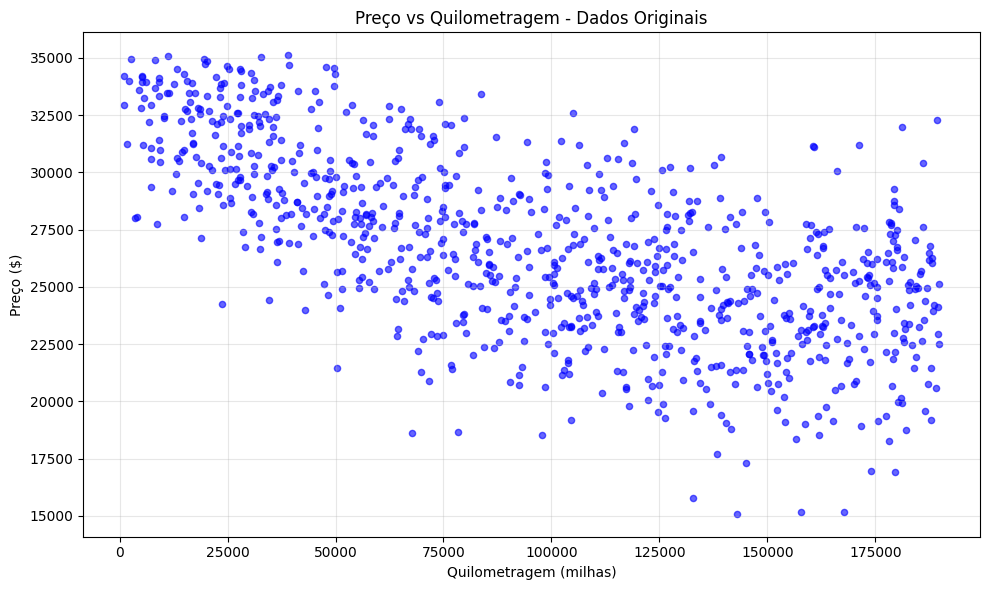


Dados de treino: 721 amostras
Dados de teste: 181 amostras

Treinando modelo polinomial de grau 2...
Modelo treinado com sucesso!

=== AVALIAÇÃO DO MODELO ===
TREINO - MSE: 8325790.88 | R²: 0.454 | RMSE: 2885.44
TESTE  - MSE: 7546821.39 | R²: 0.574 | RMSE: 2747.15


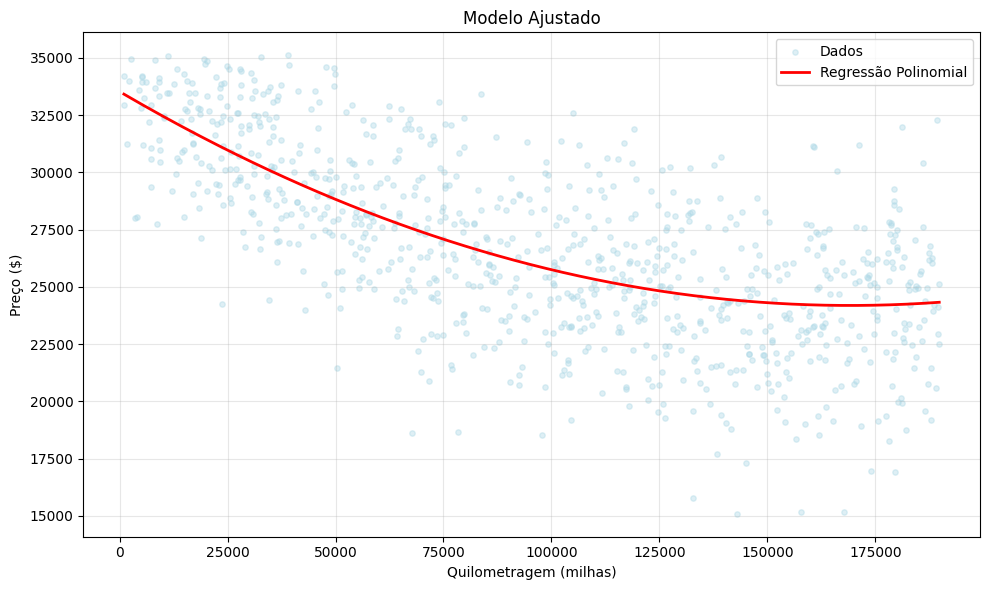

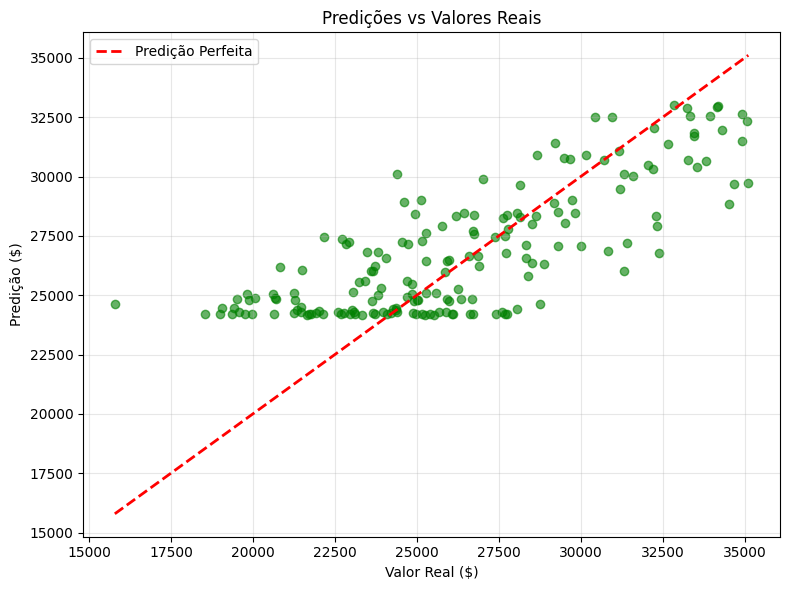

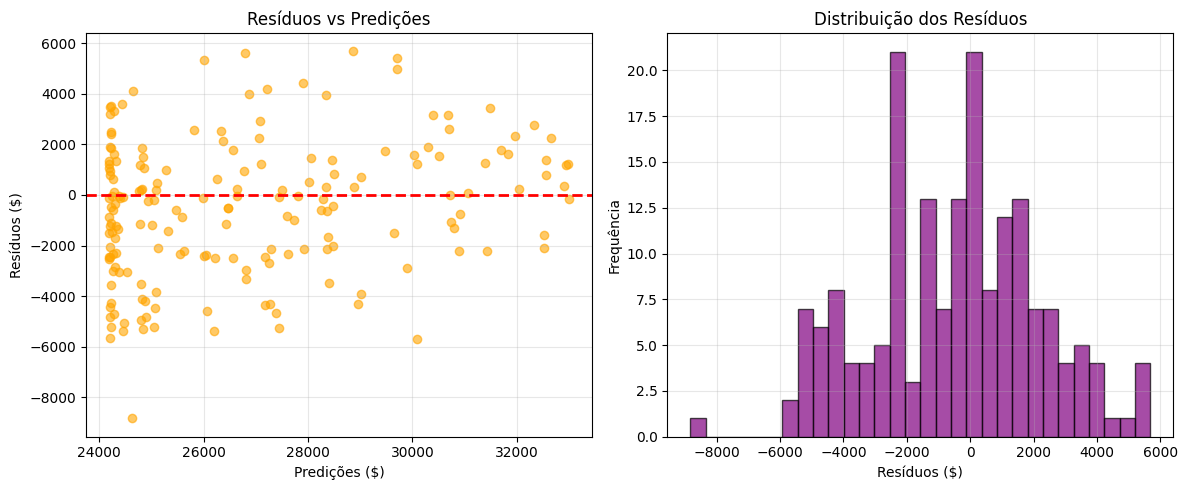


=== COMPARAÇÃO DE GRAUS ===

Treinando modelo polinomial de grau 1...
Modelo treinado com sucesso!
Grau 1: MSE = 8896152.19 | R² = 0.497

Treinando modelo polinomial de grau 2...
Modelo treinado com sucesso!
Grau 2: MSE = 7546821.39 | R² = 0.574

Treinando modelo polinomial de grau 3...
Modelo treinado com sucesso!
Grau 3: MSE = 7549828.55 | R² = 0.573

Treinando modelo polinomial de grau 4...
Modelo treinado com sucesso!
Grau 4: MSE = 7627387.95 | R² = 0.569

Treinando modelo polinomial de grau 5...
Modelo treinado com sucesso!
Grau 5: MSE = 8005853.25 | R² = 0.548


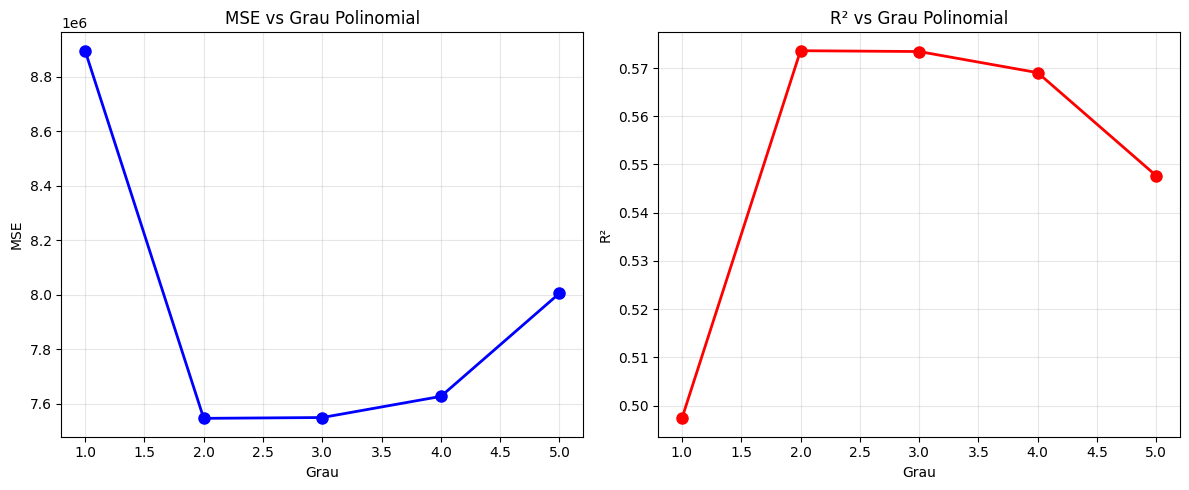


=== PREDIÇÕES PRÁTICAS ===
10,000 milhas → $32,455.25
30,000 milhas → $30,507.25
50,000 milhas → $28,820.49
75,000 milhas → $27,079.39
100,000 milhas → $25,746.47
150,000 milhas → $24,305.15

=== RESUMO FINAL ===
Melhor modelo: Grau 2
R² de teste: 0.574
RMSE de teste: $2,747.15

=== EXEMPLO DE USO ===
Carro com 75,000 milhas → Preço estimado: $27,079.39


In [60]:
# =============================================================================
#                                EXECUTAR ANÁLISE                            #
# =============================================================================

if __name__ == "__main__":
    # Executar pipeline completo
    model, poly, data, metricas = executar_pipeline_completo()

    # Exemplo de uso do modelo treinado
    print("\n=== EXEMPLO DE USO ===")
    exemplo_mileage = 75000
    preco_estimado = predicao_personalizada(model, poly, exemplo_mileage)
    print(f"Carro com {exemplo_mileage:,} milhas → Preço estimado: ${preco_estimado:,.2f}")

Regressão Logística
Introdução
Diferença da Regressão Linear
Vantagens
Desvantagens
Aplicações Práticas
Exemplo Prático - Dataset Iris:

In [61]:
# =====================================================
#                      BIBLIOTECAS                    #
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_iris

In [62]:
# =====================================================
#          CARREGAMENTO E PREPARAÇÃO DOS DADOS        #
# =====================================================

# Carregar dataset
iris = load_iris()

# Criar DataFrame
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Manter apenas duas classes (versicolor e virginica)
data = data[data['target'] != 0]
data['target'] = data['target'].map({1: 'versicolor', 2: 'virginica'})

# Visualizar informações básicas dos dados
print("Informações do dataset:")
print(f"Formato dos dados: {data.shape}")
print(f"Distribuição das classes:\n{data['target'].value_counts()}")

Informações do dataset:
Formato dos dados: (100, 5)
Distribuição das classes:
target
versicolor    50
virginica     50
Name: count, dtype: int64


In [63]:
# =====================================================
#          SEPARAÇÃO E DIVISÃO DOS DADOS              #
# =====================================================

# Separar variáveis independentes (X) e dependente (y)
X = data[iris.feature_names].values
y = data['target'].values

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nDivisão dos dados:")
print(f"Treino: {len(X_train)} amostras")
print(f"Teste: {len(X_test)} amostras")


Divisão dos dados:
Treino: 70 amostras
Teste: 30 amostras


In [64]:
# =====================================================
#               TREINAMENTO DO MODELO                #
# =====================================================

# Criar e treinar o modelo
modelo = LogisticRegression(max_iter=200)
modelo.fit(X_train, y_train)

print(f"\nModelo treinado com sucesso!")
print(f"Classes identificadas: {modelo.classes_}")


Modelo treinado com sucesso!
Classes identificadas: ['versicolor' 'virginica']


In [66]:
# =====================================================
#               PREDIÇÕES E AVALIAÇÃO                 #
# =====================================================

# Fazer predições
y_pred = modelo.predict(X_test)

# Calcular acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"\nACURÁCIA DO MODELO: {acuracia:.3f}")

# Matriz de confusão
print("\n" + "="*50)
print("MATRIZ DE CONFUSÃO:")
print("="*50)
print(confusion_matrix(y_test, y_pred))

# Relatório de classificação
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO:")
print("="*50)
print(classification_report(y_test, y_pred))



ACURÁCIA DO MODELO: 0.933

MATRIZ DE CONFUSÃO:
[[16  1]
 [ 1 12]]

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

  versicolor       0.94      0.94      0.94        17
   virginica       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [67]:
# =====================================================
#              ANÁLISE DE PROBABILIDADES              #
# =====================================================

# Obter probabilidades das predições
probabilidades = modelo.predict_proba(X_test)

print("\n" + "="*50)
print("ANÁLISE DE PROBABILIDADES (5 primeiros exemplos):")
print("="*50)

for i, prob in enumerate(probabilidades[:5]):
    print(f"Exemplo {i+1}:")
    print(f"  Probabilidades: {prob}")
    print(f"  Predição: {y_pred[i]}")
    print(f"  Valor real: {y_test[i]}")
    print(f"  Correto: {'✓' if y_pred[i] == y_test[i] else '✗'}")
    print("-" * 30)


ANÁLISE DE PROBABILIDADES (5 primeiros exemplos):
Exemplo 1:
  Probabilidades: [0.45660524 0.54339476]
  Predição: virginica
  Valor real: virginica
  Correto: ✓
------------------------------
Exemplo 2:
  Probabilidades: [0.1086376 0.8913624]
  Predição: virginica
  Valor real: virginica
  Correto: ✓
------------------------------
Exemplo 3:
  Probabilidades: [0.04365367 0.95634633]
  Predição: virginica
  Valor real: virginica
  Correto: ✓
------------------------------
Exemplo 4:
  Probabilidades: [0.9452249 0.0547751]
  Predição: versicolor
  Valor real: versicolor
  Correto: ✓
------------------------------
Exemplo 5:
  Probabilidades: [0.92043873 0.07956127]
  Predição: versicolor
  Valor real: versicolor
  Correto: ✓
------------------------------


Árvores de Regressão
Introdução
Exemplo Prático - California Housing

In [69]:
# ===============================================
#          IMPORTAÇÃO DE BIBLIOTECAS            #
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [70]:
# ===============================================
#    CARREGAMENTO E PREPARAÇÃO DOS DADOS       #
# ===============================================
# Carregar dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseValue'] = data.target

# Visualizar dados
print("Amostra dos dados:")
print(df.head())
print(f"\nShape dos dados: {df.shape}")
print(f"Informações básicas:")
print(df.info())


Amostra dos dados:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  

Shape dos dados: (20640, 9)
Informações básicas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRo

In [72]:
# ===============================================
#            PREPARAÇÃO PARA MODELAGEM          #
# ===============================================
# Separar variáveis independentes (X) e dependente (y)

X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados de treino: {X_train.shape}")
print(f"Dados de teste: {X_test.shape}")

Dados de treino: (14448, 8)
Dados de teste: (6192, 8)


In [73]:
# ===============================================
#            TREINAMENTO DO MODELO              #
# ===============================================
# Criar e treinar modelo
modelo = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [74]:
# ==============================================
#             PREDIÇÕES E AVALIAÇÃO            #
# ==============================================
# Fazer predições
y_pred = modelo.predict(X_test)

# Avaliar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n=== RESULTADOS DA AVALIAÇÃO ===")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")


=== RESULTADOS DA AVALIAÇÃO ===
Erro Quadrático Médio (MSE): 0.52
Coeficiente de Determinação (R²): 0.60


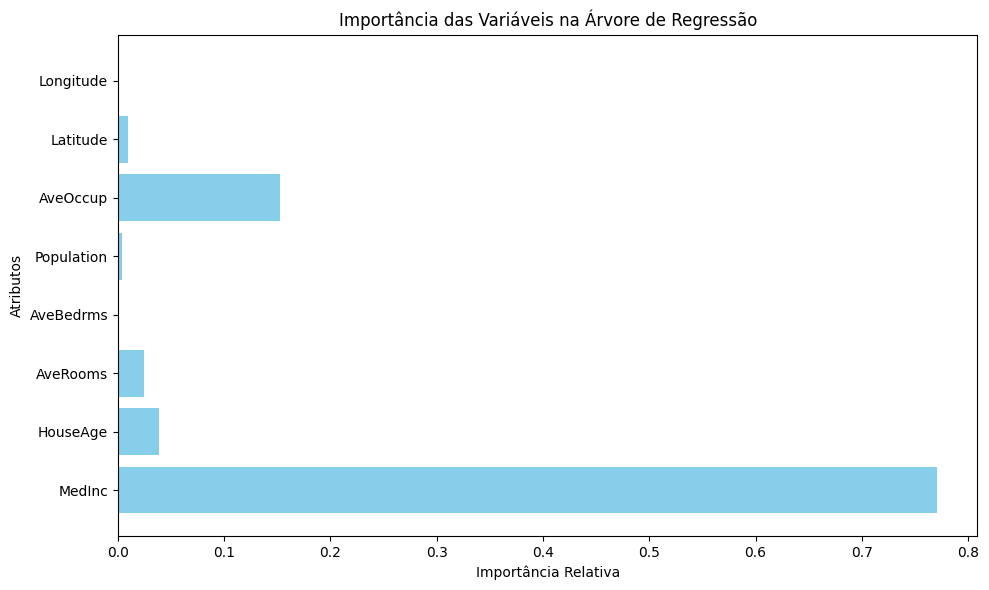

In [75]:
# ===============================================
#   VISUALIZAÇÃO - IMPORTÂNCIA DAS VARIÁVEIS   #
# ===============================================

importances = modelo.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(data.feature_names, importances, color='skyblue')
plt.xlabel('Importância Relativa')
plt.ylabel('Atributos')
plt.title('Importância das Variáveis na Árvore de Regressão')
plt.tight_layout()
plt.show()

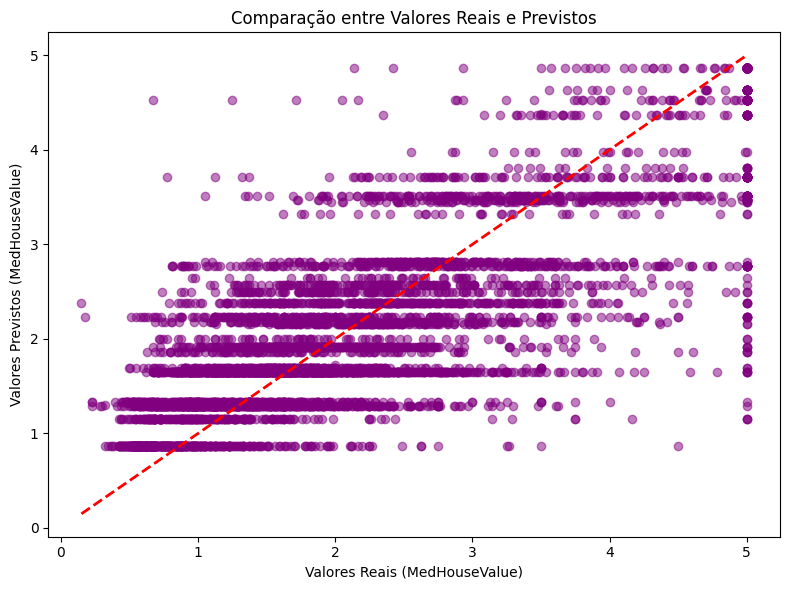

In [76]:
# ===============================================
#    VISUALIZAÇÃO - VALORES REAIS vs PREVISTOS  #
# ===============================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.xlabel("Valores Reais (MedHouseValue)")
plt.ylabel("Valores Previstos (MedHouseValue)")
plt.title("Comparação entre Valores Reais e Previstos")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.tight_layout()
plt.show()

XGBoost
Introdução
Gradient Boosting
Como Funciona
Vantagens
Desvantagens
Recursos do XGBoost
Aplicações Práticas
Exemplo Prático - California Housing

In [42]:
# ===============================================
#                    BIBLIOTECAS                #
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

In [43]:
# ===============================================
#     CARREGAMENTO E PREPARAÇÃO DOS DADOS       #
# ===============================================
# Carregar dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseValue'] = data.target

# Visualizar dados
print("Amostra dos dados:")
print(df.head())
print(f"\nShape dos dados: {df.shape}")
print(f"Informações básicas:")
print(df.info())

Amostra dos dados:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  

Shape dos dados: (20640, 9)
Informações básicas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRo

In [44]:
# ===============================================
#          PREPARAÇÃO PARA MODELAGEM            #
# ===============================================
# Separar variáveis independentes (X) e dependente (y)
X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados de treino: {X_train.shape}")
print(f"Dados de teste: {X_test.shape}")

Dados de treino: (14448, 8)
Dados de teste: (6192, 8)


In [45]:
# ===============================================
#   CONFIGURAÇÃO E TREINAMENTO DO XGBOOST       #
# ===============================================
# Criar modelo XGBoost com parâmetros otimizados
modelo = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=100,
    random_state=42
)

# Treinar modelo
print("Treinando modelo XGBoost...")
modelo.fit(X_train, y_train,
           eval_set=[(X_train, y_train), (X_test, y_test)],
           verbose=False) # Set verbose to False to avoid printing progress for each epoch
print("Modelo treinado com sucesso!")

Treinando modelo XGBoost...
Modelo treinado com sucesso!


In [46]:
# ===============================================
#           PREDIÇÕES E AVALIAÇÃO               #
# ===============================================
# Fazer predições
y_pred = modelo.predict(X_test)

# Avaliar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n=== RESULTADOS DA AVALIAÇÃO ===")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")



=== RESULTADOS DA AVALIAÇÃO ===
Erro Quadrático Médio (MSE): 0.30
Coeficiente de Determinação (R²): 0.77


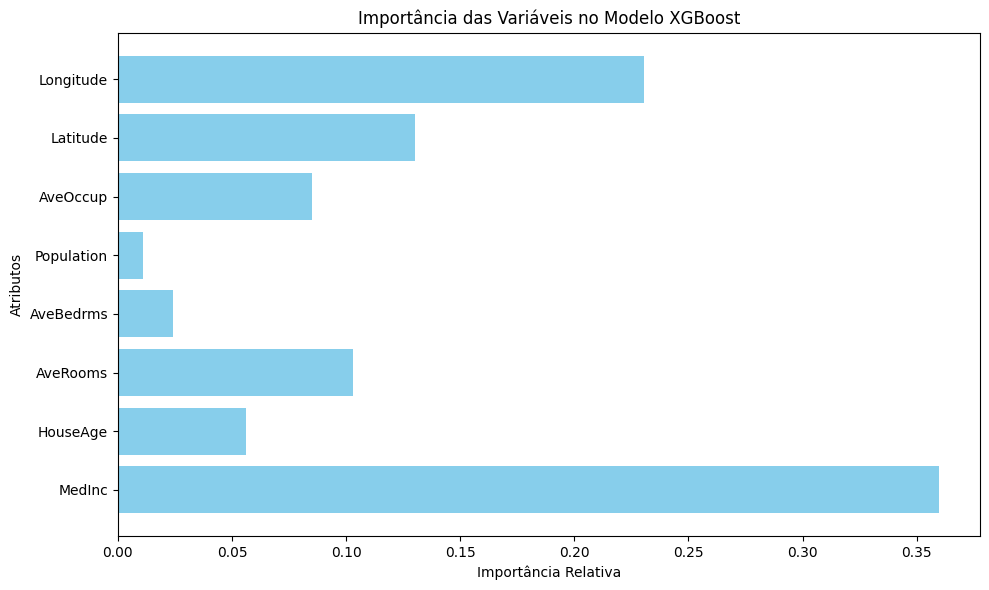

In [47]:
# ===============================================
#    VISUALIZAÇÃO - IMPORTÂNCIA DAS VARIÁVEIS  #
# ===============================================
importances = modelo.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(data.feature_names, importances, color='skyblue')
plt.xlabel('Importância Relativa')
plt.ylabel('Atributos')
plt.title('Importância das Variáveis no Modelo XGBoost')
plt.tight_layout()
plt.show()

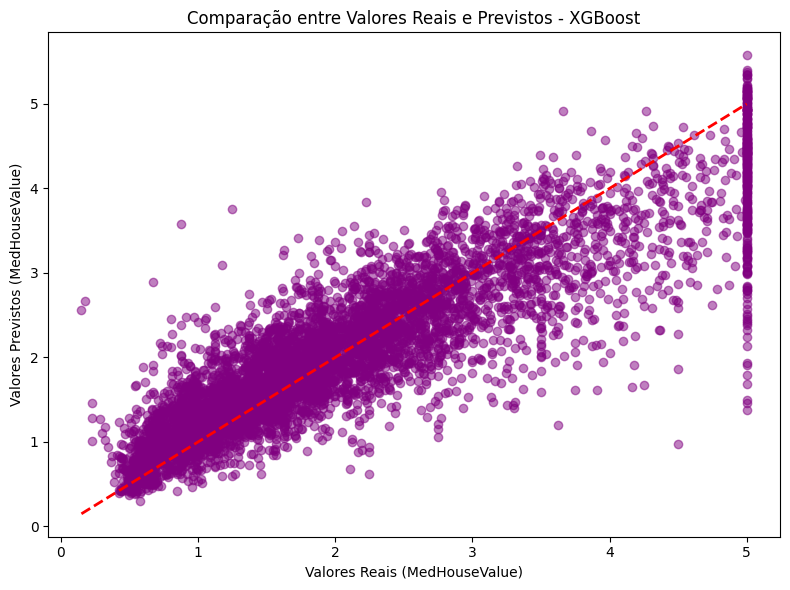

In [48]:
# ===============================================
#  VISUALIZAÇÃO - VALORES REAIS vs PREVISTOS    #
# ===============================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.xlabel("Valores Reais (MedHouseValue)")
plt.ylabel("Valores Previstos (MedHouseValue)")
plt.title("Comparação entre Valores Reais e Previstos - XGBoost")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.tight_layout()
plt.show()

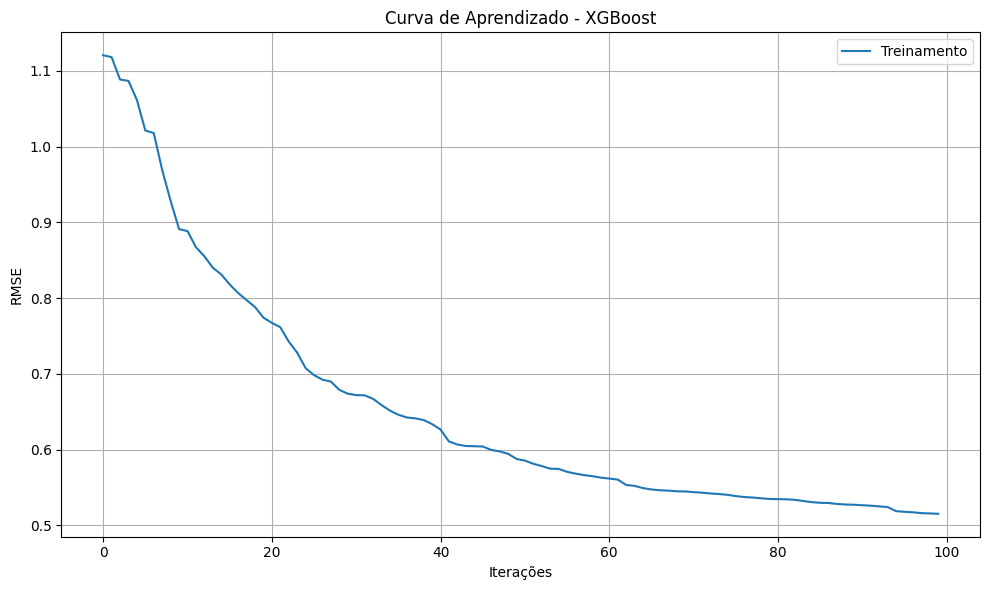

In [49]:
# ===============================================
#  ANÁLISE ADICIONAL - CURVAS DE VALIDAÇÃO     #
# ===============================================
# Avaliar performance durante o treinamento
results = modelo.evals_result()
if results:
    plt.figure(figsize=(10, 6))
    plt.plot(results['validation_0']['rmse'], label='Treinamento')
    plt.xlabel('Iterações')
    plt.ylabel('RMSE')
    plt.title('Curva de Aprendizado - XGBoost')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [50]:
# ===============================================
#          COMPARAÇÃO DE PERFORMANCE           #
# ===============================================
# Calcular métricas adicionais
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\n=== MÉTRICAS COMPLETAS ===")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

# Top 5 variáveis mais importantes
feature_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\n=== TOP 5 VARIÁVEIS MAIS IMPORTANTES ===")
print(feature_importance.head())


=== MÉTRICAS COMPLETAS ===
Erro Médio Absoluto (MAE): 0.38
Erro Quadrático Médio (MSE): 0.30
Raiz do Erro Quadrático Médio (RMSE): 0.54
Coeficiente de Determinação (R²): 0.77

=== TOP 5 VARIÁVEIS MAIS IMPORTANTES ===
     feature  importance
0     MedInc    0.359781
7  Longitude    0.230551
6   Latitude    0.130097
2   AveRooms    0.102997
5   AveOccup    0.084998


Redes Neurais
Introdução
Analogia com Aprendizado Humano
Por que são Importantes
Capacidades
Aplicações
Tipos de Redes Neurais
Algoritmo de Backpropagation
Redes Neurais Convolucionais
Treinamento de Redes Neurais
Exemplo Prático - Previsão de Compras

In [52]:
# ========================================================================
#              BIBLIOTECAS                                               #
# ========================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


In [53]:
# ========================================================================
#                         GERAÇÃO DE DADOS SINTÉTICOS                    #
# ========================================================================

print("=" * 50)
print("BLOCO 2: GERAÇÃO DE DADOS SINTÉTICOS")
print("=" * 50)

np.random.seed(42)
n_samples = 1000

# Gerando dados sintéticos mais realistas
age = np.random.normal(40, 12, n_samples)  # Idade com distribuição normal
age = np.clip(age, 18, 70).astype(int)  # Limitar entre 18 e 70

income = np.random.normal(50000, 15000, n_samples)  # Renda com distribuição normal
income = np.clip(income, 20000, 100000).astype(int)  # Limitar entre 20k e 100k

spending_score = np.random.normal(50, 20, n_samples)  # Score de gastos
spending_score = np.clip(spending_score, 1, 100).astype(int)  # Limitar entre 1 e 100

# Criar uma lógica mais complexa e realista para a variável alvo
age_factor = (age > 25) & (age < 55)  # Faixa etária mais propensa a comprar
income_factor = income > 40000  # Renda mínima
spending_factor = spending_score > 40  # Score de gastos mínimo

# Adicionar alguma aleatoriedade para tornar mais realista
noise = np.random.random(n_samples) > 0.2  # 80% de consistência

purchased = (age_factor & income_factor & spending_factor & noise).astype(int)

# Criar DataFrame
data = pd.DataFrame({
    'Age': age,
    'Annual_Income': income,
    'Spending_Score': spending_score,
    'Purchased': purchased
})

print("Dados gerados:")
print(data.head())
print(f"\nDistribuição da variável alvo:")
print(data['Purchased'].value_counts())
print(f"Proporção de compras: {data['Purchased'].mean():.2%}")

BLOCO 2: GERAÇÃO DE DADOS SINTÉTICOS
Dados gerados:
   Age  Annual_Income  Spending_Score  Purchased
0   45          70990              36          0
1   38          63869              47          1
2   47          50894              34          0
3   58          40295              43          0
4   37          60473              12          0

Distribuição da variável alvo:
Purchased
0    672
1    328
Name: count, dtype: int64
Proporção de compras: 32.80%



BLOCO 3: ANÁLISE EXPLORATÓRIA DOS DADOS


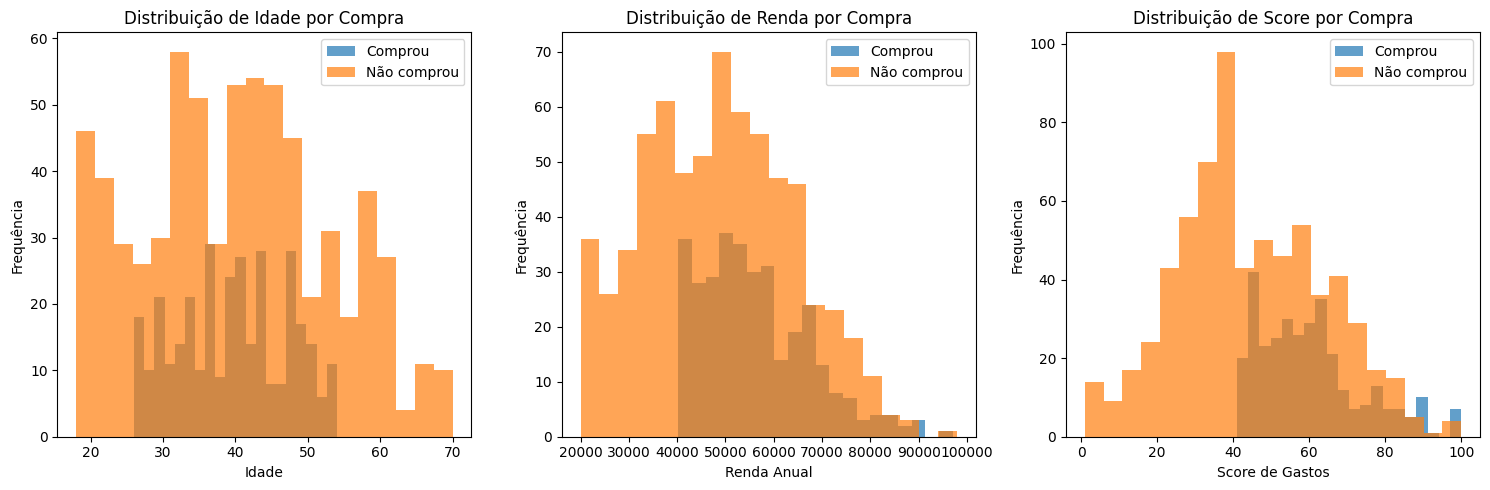

In [54]:
# ========================================================================
#                     ANÁLISE EXPLORATÓRIA DOS DADOS                     #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 3: ANÁLISE EXPLORATÓRIA DOS DADOS")
print("=" * 50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(data[data['Purchased'] == 1]['Age'], alpha=0.7, label='Comprou', bins=20)
plt.hist(data[data['Purchased'] == 0]['Age'], alpha=0.7, label='Não comprou', bins=20)
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição de Idade por Compra')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(data[data['Purchased'] == 1]['Annual_Income'], alpha=0.7, label='Comprou', bins=20)
plt.hist(data[data['Purchased'] == 0]['Annual_Income'], alpha=0.7, label='Não comprou', bins=20)
plt.xlabel('Renda Anual')
plt.ylabel('Frequência')
plt.title('Distribuição de Renda por Compra')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(data[data['Purchased'] == 1]['Spending_Score'], alpha=0.7, label='Comprou', bins=20)
plt.hist(data[data['Purchased'] == 0]['Spending_Score'], alpha=0.7, label='Não comprou', bins=20)
plt.xlabel('Score de Gastos')
plt.ylabel('Frequência')
plt.title('Distribuição de Score por Compra')
plt.legend()

plt.tight_layout()
plt.show()


In [55]:
# ========================================================================
#                    PRÉ-PROCESSAMENTO DOS DADOS                         #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 4: PRÉ-PROCESSAMENTO DOS DADOS")
print("=" * 50)

# Separar features e target
X = data[['Age', 'Annual_Income', 'Spending_Score']]
y = data['Purchased']

# Normalizar dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir dados em treino, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"Tamanho do conjunto de validação: {X_val.shape[0]}")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]}")


BLOCO 4: PRÉ-PROCESSAMENTO DOS DADOS
Tamanho do conjunto de treino: 600
Tamanho do conjunto de validação: 200
Tamanho do conjunto de teste: 200


In [56]:
# ========================================================================
#                      CONSTRUÇÃO DO MODELO                              #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 5: CONSTRUÇÃO DO MODELO")
print("=" * 50)

# Construir arquitetura da rede neural
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu', name='hidden_layer_1'),
    Dropout(0.3),  # Adicionar dropout para evitar overfitting
    Dense(32, activation='relu', name='hidden_layer_2'),
    Dropout(0.2),
    Dense(16, activation='relu', name='hidden_layer_3'),
    Dense(1, activation='sigmoid', name='output_layer')
])

# Compilar modelo
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', 'precision', 'recall']
)

# Mostrar arquitetura do modelo
print("Arquitetura do modelo:")
model.summary()


BLOCO 5: CONSTRUÇÃO DO MODELO
Arquitetura do modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# ========================================================================
#                     TREINAMENTO DO MODELO                             #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 6: TREINAMENTO DO MODELO")
print("=" * 50)

# Configurar callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Treinar modelo
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


BLOCO 6: TREINAMENTO DO MODELO
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5929 - loss: 0.6618 - precision: 0.2558 - recall: 0.1242 - val_accuracy: 0.6700 - val_loss: 0.5849 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6516 - loss: 0.5934 - precision: 0.3417 - recall: 0.0112 - val_accuracy: 0.6700 - val_loss: 0.5268 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6884 - loss: 0.5226 - precision: 0.2000 - recall: 0.0011 - val_accuracy: 0.6700 - val_loss: 0.4906 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6562 - loss: 0.5048 - precision: 0.5729 - recall: 0.0434 - val_accuracy: 0.7100 - val_loss: 0.4632 - val_precision: 0.7857 - val_recall: 0.1667
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7271 - loss: 0.4578 - precision: 0.7026 -

In [58]:
# ========================================================================
#                           AVALIAÇÃO DO MODELO                          #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 7: AVALIAÇÃO DO MODELO")
print("=" * 50)

# Avaliar modelo em todos os conjuntos
train_loss, train_accuracy, train_precision, train_recall = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy, val_precision, val_recall = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

print(f"Resultados do Treinamento:")
print(f"Treino - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")
print(f"Validação - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")
print(f"Teste - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")



BLOCO 7: AVALIAÇÃO DO MODELO
Resultados do Treinamento:
Treino - Accuracy: 0.8983, Precision: 0.7742, Recall: 0.9746
Validação - Accuracy: 0.9000, Precision: 0.7949, Recall: 0.9394
Teste - Accuracy: 0.9200, Precision: 0.8657, Recall: 0.8923



BLOCO 8: ANÁLISE DETALHADA DOS RESULTADOS
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       135
           1       0.87      0.89      0.88        65

    accuracy                           0.92       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.92      0.92      0.92       200



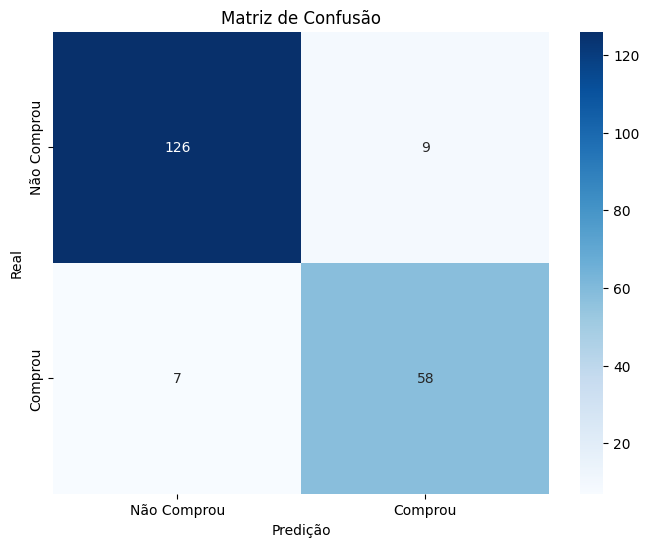

In [59]:
# ========================================================================
#                 ANÁLISE DETALHADA DOS RESULTADOS                       #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 8: ANÁLISE DETALHADA DOS RESULTADOS")
print("=" * 50)

# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_binary))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Comprou', 'Comprou'],
            yticklabels=['Não Comprou', 'Comprou'])
plt.title('Matriz de Confusão')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()


BLOCO 9: VISUALIZAÇÃO DO HISTÓRICO DE TREINAMENTO


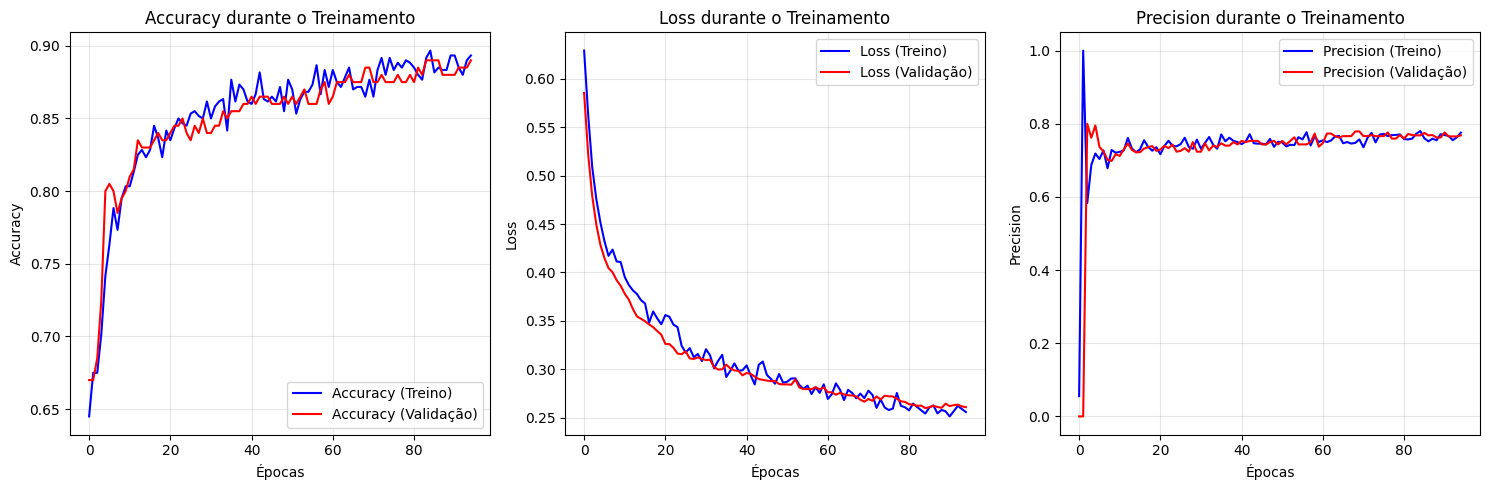

In [56]:
# ========================================================================
#            VISUALIZAÇÃO DO HISTÓRICO DE TREINAMENTO                    #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 9: VISUALIZAÇÃO DO HISTÓRICO DE TREINAMENTO")
print("=" * 50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Accuracy (Treino)', color='blue')
plt.plot(history.history['val_accuracy'], label='Accuracy (Validação)', color='red')
plt.title('Accuracy durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Loss (Treino)', color='blue')
plt.plot(history.history['val_loss'], label='Loss (Validação)', color='red')
plt.title('Loss durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history.history['precision'], label='Precision (Treino)', color='blue')
plt.plot(history.history['val_precision'], label='Precision (Validação)', color='red')
plt.title('Precision durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# ========================================================================
#                      PREDIÇÕES EM NOVOS DADOS                          #
# ========================================================================

print("\n" + "=" * 50)
print("BLOCO 10: PREDIÇÕES EM NOVOS DADOS")
print("=" * 50)

# Exemplo de predição para novos clientes
novos_clientes = np.array([
    [25, 35000, 45],  # Cliente jovem, renda média, score médio
    [45, 75000, 80],  # Cliente maduro, renda alta, score alto
    [60, 30000, 25],  # Cliente idoso, renda baixa, score baixo
])

# Normalizar novos dados usando o mesmo scaler
novos_clientes_scaled = scaler.transform(novos_clientes)
predicoes = model.predict(novos_clientes_scaled)

print("Predições para novos clientes:")
for i, (cliente, pred) in enumerate(zip(novos_clientes, predicoes)):
    prob = pred[0]
    decisao = "Comprará" if prob > 0.5 else "Não comprará"
    print(f"Cliente {i+1}: Idade={cliente[0]}, Renda={cliente[1]}, Score={cliente[2]}")
    print(f"  Probabilidade de compra: {prob:.2%}")
    print(f"  Predição: {decisao}")
    print()

print("=" * 50)
print("MODELO TREINADO E AVALIADO COM SUCESSO!")
print("=" * 50)


BLOCO 10: PREDIÇÕES EM NOVOS DADOS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predições para novos clientes:
Cliente 1: Idade=25, Renda=35000, Score=45
  Probabilidade de compra: 0.01%
  Predição: Não comprará

Cliente 2: Idade=45, Renda=75000, Score=80
  Probabilidade de compra: 83.24%
  Predição: Comprará

Cliente 3: Idade=60, Renda=30000, Score=25
  Probabilidade de compra: 0.00%
  Predição: Não comprará

MODELO TREINADO E AVALIADO COM SUCESSO!


Este documento apresentou os principais modelos de regressão e técnicas de   Machine Learning, desde os mais simples como

Regressão Linear até os mais complexos como XGBoost e Redes Neurais.

Cada técnica tem suas vantagens e aplicações específicas, e a escolha do modelo adequado depende do problema, dos dados disponíveis e dos objetivos do projeto.
